In [ ]:
import pathlib
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score, f1_score

# Set matplotlib font
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size'] = 16


## Load mapping dfs

### Lab dataset

In [19]:
map_df_paths = list(pathlib.Path(r"C:\Users\Ana-Jade\OneDrive\Documents\Ecole\TUHH\Semester 6\Masterarbeit\OCT_lab_data\512mscans_noNoise_sample20").glob('*.csv'))
map_df_paths = [p for p in map_df_paths if '_Classes3_' in p.__str__()]
[print(p) for p in map_df_paths]
lab_dfs = pd.concat([pd.read_csv(p) for p in map_df_paths], axis=0).copy()
lab_dfs['img_relative_path'] = [pathlib.Path(p) for p in lab_dfs['img_relative_path']]
lab_dfs.loc[:, 'area'] = [p.parent.name.split('_')[-1] for p in lab_dfs['img_relative_path']]
lab_dfs

C:\Users\Ana-Jade\OneDrive\Documents\Ecole\TUHH\Semester 6\Masterarbeit\OCT_lab_data\512mscans_noNoise_sample20\test_mapping_Classes3_Sine_512scans.csv
C:\Users\Ana-Jade\OneDrive\Documents\Ecole\TUHH\Semester 6\Masterarbeit\OCT_lab_data\512mscans_noNoise_sample20\train_mapping_Classes3_Sine_512scans.csv
C:\Users\Ana-Jade\OneDrive\Documents\Ecole\TUHH\Semester 6\Masterarbeit\OCT_lab_data\512mscans_noNoise_sample20\valid_mapping_Classes3_Sine_512scans.csv


,img_relative_path,label,old_label,idx_start,idx_end,subset,area
0,512mscans_noNoise_sample20\chicken_heart_p2_ar...,chicken_heart_muscle,chicken_heart,1,512,test,area6
1,512mscans_noNoise_sample20\chicken_heart_p2_ar...,chicken_heart_muscle,chicken_heart,513,1024,test,area6
2,512mscans_noNoise_sample20\chicken_heart_p2_ar...,chicken_heart_muscle,chicken_heart,1025,1536,test,area6
3,512mscans_noNoise_sample20\chicken_heart_p2_ar...,chicken_heart_muscle,chicken_heart,1537,2048,test,area6
4,512mscans_noNoise_sample20\chicken_heart_p2_ar...,chicken_heart_muscle,chicken_heart,2049,2560,test,area6
...,...,...,...,...,...,...,...
4618,512mscans_noNoise_sample20\lamb_testicle_area3...,lamb_testicle,lamb_testicle,115713,116224,valid,area3
4619,512mscans_noNoise_sample20\lamb_testicle_area3...,lamb_testicle,lamb_testicle,116225,116736,valid_supervised,area3
4620,512mscans_noNoise_sample20\lamb_testicle_area3...,lamb_testicle,lamb_testicle,116737,117248,valid,area3
4621,512mscans_noNoise_sample20\lamb_testicle_area3...,lamb_testicle,lamb_testicle,117249,117760,valid,area3


### Clinical dataset

In [14]:
# Clinical data
map_df_paths = list(pathlib.Path(r"Y:\OCT_clinical_data\512mscans_sample20").glob('*.csv'))
map_df_paths = [p for p in map_df_paths if 'old' not in p.__str__()]
[print(p) for p in map_df_paths]
cli_dfs = pd.concat([pd.read_csv(p) for p in map_df_paths], axis=0)
cli_dfs['img_relative_path'] = [pathlib.Path(p) for p in cli_dfs['img_relative_path']]
cli_dfs.loc[:, 'area'] = [p.parent.name.split('_')[-1] for p in cli_dfs['img_relative_path']]
# cli_dfs.loc[:, 'pat'] = [int(re.sub(r'[^\d]+', '', p.parts[1])) for p in cli_dfs['img_relative_path']]
cli_dfs.loc[:, 'trajectory'] = ['_'.join(p.stem.split('_')[:-3]) for p in cli_dfs.loc[:, 'img_relative_path']]
cli_dfs

Y:\OCT_clinical_data\512mscans_sample20\test_mapping_512scans.csv
Y:\OCT_clinical_data\512mscans_sample20\train_mapping_512scans.csv
Y:\OCT_clinical_data\512mscans_sample20\valid_mapping_512scans.csv


,img_relative_path,label,idx_start,idx_end,subset,area,trajectory
0,512mscans_sample20\pat01\pat01_vc_re_run2_1702...,Healthy,1,512,test,pat01,pat01_vc_re_run2
1,512mscans_sample20\pat01\pat01_vc_re_run2_1702...,Healthy,513,1024,test,pat01,pat01_vc_re_run2
2,512mscans_sample20\pat01\pat01_vc_re_run2_1702...,Healthy,1025,1536,test,pat01,pat01_vc_re_run2
3,512mscans_sample20\pat01\pat01_vc_re_run2_1702...,Healthy,1537,2048,test,pat01,pat01_vc_re_run2
4,512mscans_sample20\pat01\pat01_vc_re_run2_1702...,Healthy,2049,2560,test,pat01,pat01_vc_re_run2
...,...,...,...,...,...,...,...
508,512mscans_sample20\pat11\pat11_vc_re_run1_1724...,Healthy,44033,44544,valid,pat11,pat11_vc_re_run1
509,512mscans_sample20\pat11\pat11_vc_re_run1_1724...,Healthy,44545,45056,valid,pat11,pat11_vc_re_run1
510,512mscans_sample20\pat11\pat11_vc_re_run1_1724...,Healthy,45057,45568,valid,pat11,pat11_vc_re_run1
511,512mscans_sample20\pat11\pat11_vc_re_run1_1724...,Healthy,45569,46080,valid,pat11,pat11_vc_re_run1


## Obsolete

### Check label and area distribution in lab test set

In [32]:
lab_test_map = pd.read_csv(r"C:\Users\anaja\OneDrive\Documents\Ecole\TUHH\Semester 6\Masterarbeit\OCT_lab_data\512mscans_noNoise_sample20\test_mapping_512scans.csv")
ascan_per_group = lab_test_map['idx_end'].iloc[0]
lab_test_map.loc[:, 'img_relative_path'] = [pathlib.Path(p) for p in lab_test_map.loc[:,'img_relative_path']]
lab_test_map = lab_test_map.rename(columns={'label': 'label_str'})
labels_dict = {i: lbl for i, lbl in enumerate(['chicken_heart', 'chicken_stomach', 'lamb_heart', 'lamb_testicle'])}
for i, lbl in labels_dict.items():
   lab_test_map.loc[lab_test_map['label_str'] == lbl, 'label'] = i
lab_test_map['area'] = [re.sub('|'.join(f'{f}_' for f in labels_dict.values()), '', p.parts[1]) for p in lab_test_map['img_relative_path']]
lab_test_map['trajectory'] = ['_'.join(p.stem.split('_')[:-2]) for p in lab_test_map['img_relative_path']]
lab_test_map['area_id'] = lab_test_map.groupby(['label', 'area']).ngroup()

# Add traj_type
for i, traj_type in enumerate(['jitter', 'line', 'sine']):
    lab_test_map.loc[lab_test_map['trajectory'].str.contains(traj_type), 'traj_type'] = i

# Assign subset
# lab_test_map.loc[:, 'subset'] = -1
# lab_test_map.loc[lab_test_map.index%5 <= 2, 'subset'] = 'test_train'
# lab_test_map.loc[lab_test_map.index%5 == 3, 'subset'] = 'test_valid'
# lab_test_map.loc[lab_test_map.index%5 == 4, 'subset'] = 'test_test'
    
# Assign subset V2
lab_test_map.loc[:, 'subset'] = lab_test_map.groupby(['area_id', 'trajectory']).cumcount()
lab_test_map.loc[lab_test_map['subset']%10 == 9, 'subset'] = 'test_supervised'
lab_test_map.loc[lab_test_map['subset'] != 'test_supervised', 'subset'] = 'test'

lab_test_map

,img_relative_path,label_str,idx_start,idx_end,label,area,trajectory,area_id,traj_type,subset
0,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,1,512,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test
1,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,513,1024,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test
2,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,1025,1536,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test
3,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,1537,2048,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test
4,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,2049,2560,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test
...,...,...,...,...,...,...,...,...,...,...
15283,512mscans_noNoise_sample20\lamb_testicle_area8...,lamb_testicle,113665,114176,3.0,area8,lamb_testicle_area8_sine_5x5y_s8_zamp05,7,2.0,test
15284,512mscans_noNoise_sample20\lamb_testicle_area8...,lamb_testicle,114177,114688,3.0,area8,lamb_testicle_area8_sine_5x5y_s8_zamp05,7,2.0,test
15285,512mscans_noNoise_sample20\lamb_testicle_area8...,lamb_testicle,114689,115200,3.0,area8,lamb_testicle_area8_sine_5x5y_s8_zamp05,7,2.0,test
15286,512mscans_noNoise_sample20\lamb_testicle_area8...,lamb_testicle,115201,115712,3.0,area8,lamb_testicle_area8_sine_5x5y_s8_zamp05,7,2.0,test


In [34]:
lab_test_map.groupby(['area_id', 'traj_type', 'subset']).agg(img_count=('img_relative_path', 'count'), idx_start_mean=('idx_start', 'mean'))

img_count  idx_start_mean
area_id traj_type subset                                    
0       0.0       test                   354    35778.807910
                  test_supervised         38    37215.315789
        1.0       test                   486    47037.576132
                  test_supervised         53    48853.528302
        2.0       test                   881    89222.666288
                  test_supervised         97    90857.247423
1       0.0       test                   334    32252.401198
                  test_supervised         35    32842.142857
        1.0       test                   464    44999.620690
                  test_supervised         50    46388.200000
        2.0       test                   856    86516.439252
                  test_supervised         93    87079.537634
2       0.0       test                   413    41569.697337
                  test_supervised         44    42194.454545
        1.0       test                   473    45589.566596
                  test_supervised         52    47636.692308
        2.0       test                   884    88623.334842
                  test_supervised         97    90171.061856
3       0.0       test                   326    36282.325153
                  test_supervised         35    38401.000000
        1.0       test                   466    45455.832618
                  test_supervised         50    46388.200000
        2.0       test                   856    86549.336449
                  test_supervised         93    87079.537634
4       0.0       test                   364    41087.593407
                  test_supervised         39    42155.666667
        1.0       test                   464    44760.172414
                  test_supervised         50    46388.200000
        2.0       test                   793    79823.930643
                  test_supervised         86    80932.720930
5       0.0       test                   451    43967.155211
                  test_supervised         49    45673.489796
        1.0       test                   494    47573.469636
                  test_supervised         53    48853.528302
        2.0       test                   892    89844.372197
                  test_supervised         98    91544.510204
6       0.0       test                   472    44718.559322
                  test_supervised         50    45159.400000
        1.0       test                   489    47263.102249
                  test_supervised         53    48853.528302
        2.0       test                   756    76053.317460
                  test_supervised         82    77163.146341
7       0.0       test                   512    49310.000000
                  test_supervised         55    50130.454545
        1.0       test                   494    47573.469636
                  test_supervised         53    48853.528302
        2.0       test                   820    80806.463415
                  test_supervised         89    81696.640449

In [19]:
subset = 'test_supervised'
lab_test_map[lab_test_map['subset'] == f'test_{subset}']

,img_relative_path,label_str,idx_start,idx_end,label,area,trajectory,area_id,traj_type,subset
0,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,1,512,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test_train
1,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,513,1024,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test_train
2,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,1025,1536,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test_train
5,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,2561,3072,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test_train
6,512mscans_noNoise_sample20\chicken_heart_p1_ar...,chicken_heart,3073,3584,0.0,p1_area2,chicken_heart_p1_area2_jitter_20p_2x_2y_15z_s3,0,0.0,test_train
...,...,...,...,...,...,...,...,...,...,...
15281,512mscans_noNoise_sample20\lamb_testicle_area8...,lamb_testicle,112641,113152,3.0,area8,lamb_testicle_area8_sine_5x5y_s8_zamp05,7,2.0,test_train
15282,512mscans_noNoise_sample20\lamb_testicle_area8...,lamb_testicle,113153,113664,3.0,area8,lamb_testicle_area8_sine_5x5y_s8_zamp05,7,2.0,test_train
15285,512mscans_noNoise_sample20\lamb_testicle_area8...,lamb_testicle,114689,115200,3.0,area8,lamb_testicle_area8_sine_5x5y_s8_zamp05,7,2.0,test_train
15286,512mscans_noNoise_sample20\lamb_testicle_area8...,lamb_testicle,115201,115712,3.0,area8,lamb_testicle_area8_sine_5x5y_s8_zamp05,7,2.0,test_train


In [20]:
lab_test_map.groupby(['subset']).agg(img_count=('img_relative_path', 'count'), idx_start_mean=('idx_start', 'mean'))

,img_count,idx_start_mean
subset,,
test_test,3057,64182.888126
test_train,9174,64151.240244
test_valid,3057,64194.947007


### Plot results V0

In [1]:
results_simclr = {'ResNet18': {'Supervised': {'F1 score': 48, 'Accuracy': 46}, 'Finetune': {'F1 score': 50, 'Accuracy': 49}},
           'EfficientNetV2-S': {'Supervised': {'F1 score': 53, 'Accuracy': 52}, 'Finetune': {'F1 score': 55, 'Accuracy': 53}}, 
           'ConvNeXt-Tiny': {'Supervised': {'F1 score': 49, 'Accuracy': 47}, 'Finetune': {'F1 score': 53, 'Accuracy': 52}}, 
           'PVT-V2-B0': {'Supervised': {'F1 score': 56, 'Accuracy': 55}, 'Finetune': {'F1 score': 51, 'Accuracy': 52}}}


results_byol = {'ResNet18': {'Supervised': {'F1 score': 48, 'Accuracy': 46}, 'Finetune': {'F1 score': 51, 'Accuracy': 51}},
           'EfficientNetV2-S': {'Supervised': {'F1 score': 53, 'Accuracy': 52}, 'Finetune': {'F1 score': 45, 'Accuracy': 47}}, 
           'ConvNeXt-Tiny': {'Supervised': {'F1 score': 49, 'Accuracy': 47}, 'Finetune': {'F1 score': 55, 'Accuracy': 53}}, 
           'PVT-V2-B0': {'Supervised': {'F1 score': 56, 'Accuracy': 55}, 'Finetune': {'F1 score': 57, 'Accuracy': 57}}}

results_simclr_df = pd.concat({m: pd.DataFrame.from_dict(res, orient='columns') for m, res in results_simclr.items()}).reset_index().rename(columns={'level_0': 'Model', 'level_1': 'Metric'})
results_simclr_df = pd.pivot_table(results_simclr_df, values=['Supervised', 'Finetune'], index='Model', columns='Metric').swaplevel(axis=1)
results_simclr_df.columns.set_names('Train type', level=1, inplace=True)
# results_simclr_df
# results_simclr_df['Accuracy'].plot.bar(rot=0, title='', ylabel='Accuracy')

In [42]:
f1_results = {'ResNet18': {'Supervised': 48, 'Finetune-SimCLR': 50, 'Finetune-BYOL': 51},
           'EfficientNetV2-S': {'Supervised': 53, 'Finetune-SimCLR': 55, 'Finetune-BYOL': 45}, 
           'ConvNeXt-Tiny': {'Supervised': 49, 'Finetune-SimCLR': 53, 'Finetune-BYOL': 55}, 
           'PVT-V2-B0': {'Supervised': 56, 'Finetune-SimCLR': 51, 'Finetune-BYOL': 57}}
acc_results = {'ResNet18': {'Supervised': 46, 'Finetune-SimCLR': 49, 'Finetune-BYOL': 51},
           'EfficientNetV2-S': {'Supervised': 52, 'Finetune-SimCLR': 53, 'Finetune-BYOL': 47}, 
           'ConvNeXt-Tiny': {'Supervised': 47, 'Finetune-SimCLR': 52, 'Finetune-BYOL': 53}, 
           'PVT-V2-B0': {'Supervised': 55, 'Finetune-SimCLR': 52, 'Finetune-BYOL': 57}}
f1_results = pd.DataFrame.from_dict(f1_results, orient='index')
acc_results = pd.DataFrame.from_dict(acc_results, orient='index')

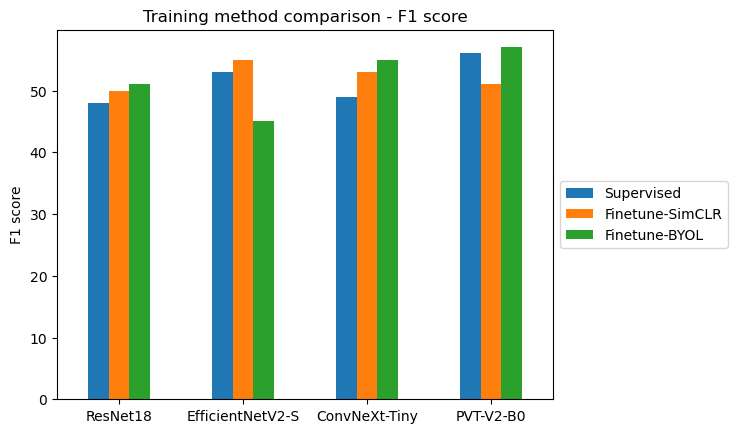

In [52]:
ax_f1 = f1_results.plot.bar(rot=0, ylabel='F1 score', title='Training method comparison - F1 score')
ax_f1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

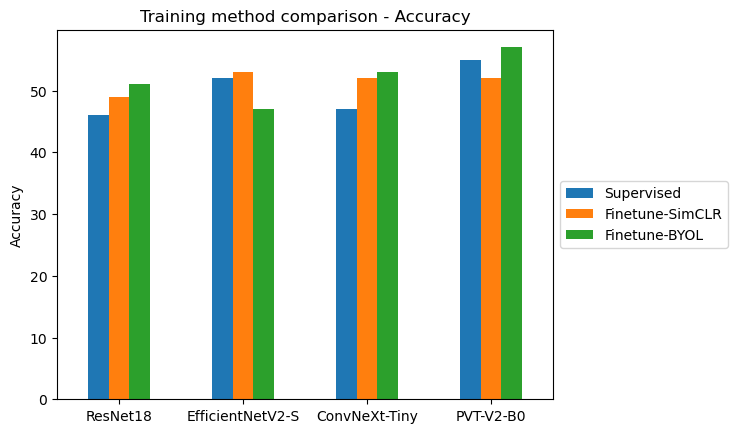

In [53]:
ax_acc = acc_results.plot.bar(rot=0, ylabel='Accuracy', title='Training method comparison - Accuracy')
ax_acc.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

<Axes: xlabel='Model', ylabel='Accuracy'>

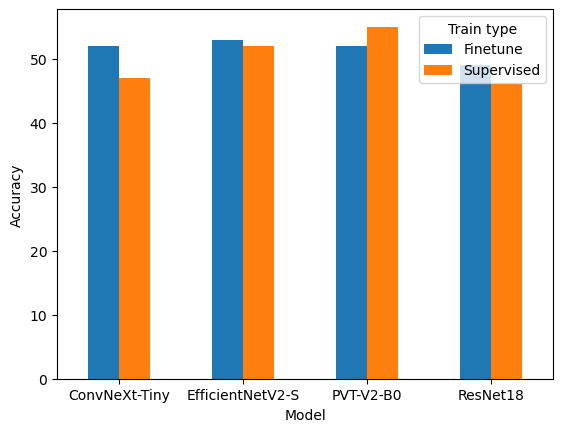

## Lab dataset stats

In [18]:
print(f"Total image count: {lab_dfs.groupby(['label']).agg(img_count=('img_relative_path', 'count')).sum()}")
lab_dfs.groupby(['label']).agg(img_count=('img_relative_path', 'count'))

Total image count: img_count    16466
dtype: int64


,img_count
label,
chicken_heart_muscle,3501
lamb_heart_fat,2800
lamb_heart_muscle,3369
lamb_liver,3107
lamb_testicle,3689


In [21]:
pd.merge(lab_dfs.groupby(['label', 'area']).agg(img_count=('img_relative_path', 'count')).reset_index(), lab_dfs[['label', 'old_label', 'area']].drop_duplicates(subset=['label', 'area']))

,label,area,img_count,old_label
0,chicken_heart_muscle,area1,585,chicken_heart
1,chicken_heart_muscle,area2,978,chicken_heart
2,chicken_heart_muscle,area4,989,chicken_heart
3,chicken_heart_muscle,area6,949,chicken_heart
4,lamb_heart_fat,area1,591,lamb_heart
5,lamb_heart_fat,area2,352,lamb_heart
6,lamb_heart_fat,area3,879,lamb_heart
7,lamb_heart_fat,area4,978,lamb_heart
8,lamb_heart_muscle,area5,759,lamb_heart
9,lamb_heart_muscle,area6,820,lamb_heart


In [ ]:
lab_dfs.groupby(['label', 'subset']).agg(img_count=('img_relative_path', 'count'))

## Get clinical data stats

### Double check labels

In [23]:
lbl_paths = list(pathlib.Path(r'Y:\OCT_clinical_data\Labels').rglob('*.csv'))
lbls = {'_'.join(p.stem.split('_')[:-2]): pd.read_csv(p) for p in lbl_paths}
empty_lbl_df = []
for t, lbl_df in lbls.items():
    try:
        lbl_df.loc[:, 'traj'] = t
    except ValueError:
        empty_lbl_df.append(t)
print(f"Empty dfs for {empty_lbl_df}")
lbls = pd.concat(lbls.values(), axis=0)
lbls.loc[:, 'area'] = [t.split('_')[0] for t in lbls['traj']]

# Remove specific traj
traj_to_remove = ['pat01_vc_re_run1', 'pat04_vc_le_run1', 'pat04_vc_le_run3', 'pat04_vc_re_run2', 'pat06_vc_re_run1', 'pat07_vc_re_run1', 'pat15_vc_le_run1']
print(f"Removing {len(traj_to_remove)} of {len(lbls['traj'].unique())} trajectories")
lbls = lbls[~lbls['traj'].isin(traj_to_remove)].copy()
print(f"{len(lbls['traj'].unique())} remaining.")
lbls = lbls.groupby(['area', 'traj']).agg({'Label': lambda x: ', '.join(x.unique())}).reset_index()
lbls

Empty dfs for ['pat03_vc_re_run1', 'pat03_vc_re_run2', 'pat03_vc_re_run3', 'pat10_vc_le_run1', 'pat12_vc_le_run1', 'pat12_vc_le_run2', 'pat12_vc_le_run3', 'pat14_vc_le_run1', 'pat14_vc_le_run2', 'pat14_vc_le_run3', 'pat16_vc_le_run1', 'pat16_vc_le_run2', 'pat16_vc_re_run1']
Removing 7 of 35 trajectories
28 remaining.


,area,traj,Label
0,pat01,pat01_vc_re_run2,Healthy
1,pat02,pat02_vc_le_run1,Healthy
2,pat02,pat02_vc_re_run1,Lesion
3,pat02,pat02_vc_re_run2,Lesion
4,pat04,pat04_vc_re_run3,Healthy
5,pat07,pat07_vc_le_run1,Lesion
6,pat07,pat07_vc_re_run2,Healthy
7,pat08,pat08_VC_le_run1,Lesion
8,pat08,pat08_VC_le_run2,Lesion
9,pat08,pat08_VC_le_run3,Healthy


In [24]:
# Double check to make sure labels match
lbls = pd.merge(cli_dfs, lbls, left_on=['area', 'trajectory'], right_on=['area', 'traj']).drop(columns=['traj']).rename(columns={'Label': 'label_og'})
lbls[lbls['label'] != lbls['label_og']]

,img_relative_path,label,idx_start,idx_end,subset,area,trajectory,label_og


### Img count

In [25]:
print(f"{len(cli_dfs['area'].unique())} patients")
print(f"{len(cli_dfs)} images")
cli_dfs.groupby(['area']).agg(img_count=('img_relative_path', 'count')).reset_index()

11 patients
2113 images


,area,img_count
0,pat01,12
1,pat02,237
2,pat04,195
3,pat07,159
4,pat08,257
5,pat09,70
6,pat10,268
7,pat11,284
8,pat13,178
9,pat15,168


In [30]:
cli_dfs.groupby('subset').agg(img_count=('img_relative_path', 'nunique'))

,img_count
subset,
test,615
train,985
valid,513


In [31]:
cli_dfs.groupby(['subset', 'label']).agg(img_count=('img_relative_path', 'nunique'))

img_count
subset label             
test   Healthy        222
       Lesion         393
train  Healthy        476
       Lesion         509
valid  Healthy        233
       Lesion         280

In [ ]:
cli_dfs.groupby(['area', 'trajectory']).agg(img_count=('img_relative_path', 'count')).reset_index()
# pd.merge(cli_dfs.groupby(['label', 'area', 'trajectory']).agg(img_count=('img_relative_path', 'count')).reset_index(), cli_dfs[['label', 'area']].drop_duplicates(subset=['label', 'area']))

In [ ]:
split0 = {'train': ['pat02', 'pat04', 'pat10', 'pat16'], 'valid': ['pat07', 'pat09', 'pat11'], 'test': ['pat01', 'pat08', 'pat13', 'pat15']}
split1 = {'train': ['pat10', 'pat09', 'pat11', 'pat01'], 'valid': ['pat04', 'pat13', 'pat16'], 'test': ['pat08', 'pat02', 'pat07', 'pat15']}
split2 = {'train': ['pat10', 'pat11', 'pat16', 'pat07'], 'valid': ['pat04', 'pat15', 'pat01'], 'test': ['pat09', 'pat08', 'pat02', 'pat13']}

## Plot experiment 1 results

In [143]:
def find_pred_files(folder_path: pathlib.Path, dataset_name:str) -> list:
    files = list(folder_path.glob('*.csv'))
    if dataset_name == 'oct':
        files = [p for p in files if 'clinical' not in p.__str__()]
    else:
        files = [p for p in files if 'clinical' in p.__str__()]
    return files

def merge_pred_csv(pred_paths: list)-> pd.DataFrame:
    preds = {p: pd.read_csv(p) for p in pred_paths}
    preds_all = pd.DataFrame()
    for p, df in preds.items():
        if ('random' in p.stem) or ('default' in p.stem):
            starting_weights = p.stem.split('_')[-1]
            ratio_sup = int(re.sub(r'[^\d]+', '', p.stem.split('_')[-2]))
        else:
            starting_weights = p.parent.parent.stem
            ratio_sup = int(re.sub(r'[^\d]+', '', p.stem.split('_')[-1]))
        col_name = f"{starting_weights}_{re.sub(r'[^\w\s]', '', f'{ratio_sup:03d}')}"
        # print(col_name)
        df = df.rename(columns={'pred': f'pred_{col_name}'})
        df = df.set_index([c for c in df.columns if 'pred' not in c])
        if len(preds_all) == 0:
            preds_all = df.copy()
        else:
            preds_all = pd.merge(preds_all, df, left_index=True, right_index=True, how='outer')
    preds_all = preds_all.reindex(sorted(preds_all.columns), axis=1)
    return preds_all

def get_f1_score_per_col(df: pd.DataFrame, keep_weight_init=True) -> dict:
    pred_cols = [c for c in df.columns if 'pred' in c]
    df = df.reset_index()
    f1_dict = {}
    for c in pred_cols:
        df_c = df.dropna(subset=[c])
        # f1s_c = f1_score(df_c['label'].tolist(), df_c[c].tolist(), average=None) # F1 score per class
        f1_c = f1_score(df_c['label'].tolist(), df_c[c].tolist(), average='macro') # Mean of F1 scores per class
        if keep_weight_init:
            f1_dict[c] = f1_c
        else:
            new_c = c.split('_')[-1]
            f1_dict[new_c] = f1_c
    return f1_dict

In [ ]:
model_archs = {'resnet18': 'ResNet-18', 'pvtv2b0': 'PVTv2-b0', 'mobilenetv3': 'MobileNetV3'}
model_arch = list(model_archs.keys())[2]
datasets = {'oct': 'lab', 'oct_clincal': 'clinical'}
dataset = list(datasets.keys())[0]

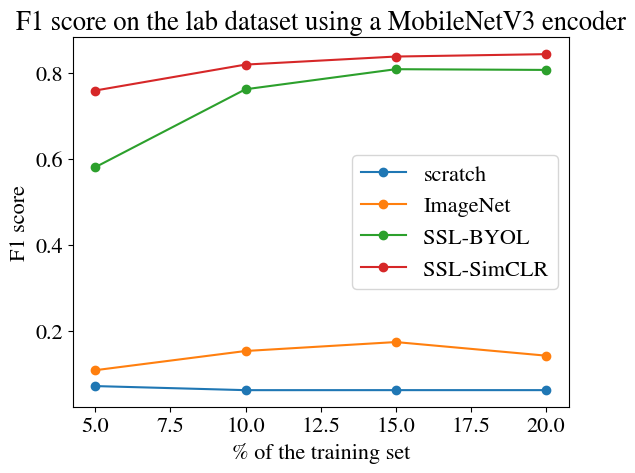

In [192]:
# Load all pred files
# MAKE SURE FILES HAVE BEEN DOWNLOADED FROM THE HPC
# Define base folder paths
supervised_folder = pathlib.Path.cwd().joinpath('supervised').joinpath(f'weights_{model_arch}')
byol_folder = pathlib.Path.cwd().joinpath('BYOL').joinpath(f'weights_{model_arch}')
simclr_folder = pathlib.Path.cwd().joinpath('SimCLR').joinpath(f'weights_{model_arch}')

# Find pred files
supervised_pred_files = find_pred_files(supervised_folder, dataset)
byol_pred_files = find_pred_files(byol_folder, dataset)
simclr_pred_files = find_pred_files(simclr_folder, dataset)

# Split random vs imagenet preds
supervised_pred_random_files = [p for p in supervised_pred_files if 'random' in p.__str__()]
supervised_pred_imagenet_files = [p for p in supervised_pred_files if 'default' in p.__str__()]

# Load preds as csv
supervised_preds_random = merge_pred_csv(supervised_pred_random_files)
supervised_preds_imagenet = merge_pred_csv(supervised_pred_imagenet_files)
byol_preds = merge_pred_csv(byol_pred_files)
simclr_preds = merge_pred_csv(simclr_pred_files)

# Get mAP per col
all_preds = {'scratch': supervised_preds_random, 'ImageNet': supervised_preds_imagenet, 'SSL-BYOL': byol_preds, 'SSL-SimCLR': simclr_preds}
f1_overview = {}
for w, preds in all_preds.items():
    f1_overview[w] = get_f1_score_per_col(preds, keep_weight_init=False)
f1_overview = pd.DataFrame.from_dict(f1_overview, orient='columns')
f1_overview.index = [int(i) for i in f1_overview.index]
f1_overview = f1_overview.reset_index().rename(columns={'index': 'train_ratio'})
# f1_overview
plt_title = f"F1 score on the {datasets[dataset]} dataset using a {model_archs[model_arch]} encoder"
f1_overview.plot.line(x='train_ratio', y=[c for c in f1_overview if c != 'train_ratio'], 
                      title=plt_title,
                      xlabel=r'% of the training set',
                      ylabel='F1 score',
                      marker='o')
plt.savefig(f'F1score_{model_arch}_{dataset}.png', dpi=500)
